In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import json
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

Segmentation Plan: Use predictions from catboost model -> clean features -> clustering algorithm -> customer profiling

## Running catboost model on full dataset for segmentation

In [ ]:
from catboost import CatBoostClassifier,Pool
cb_clf = CatBoostClassifier()
cb_clf.load_model('../model/catboost_model')

CatBoostClassifier(bagging_temperature=0.5733272884, depth=6, eval_metric='PRAUC', iterations=3000, l2_leaf_reg=4.234523019, learning_rate=0.06060514682, loss_function='Logloss', od_wait=100, random_seed=131, random_strength=0.7921427827, verbose=100)

In [ ]:
data_file_path = '../data/censusbureau.data'
columns_file_path = '../data/census-bureau.columns'
with open(columns_file_path, 'r') as f:
    columns = [line.strip() for line in f if line.strip()]
df = pd.read_csv(data_file_path, header=None)
df.columns = columns


target = 'label'
weight_column = 'weight'
continuous_columns = ['age','wage per hour','capital gains','capital losses','dividends from stocks','num persons worked for employer','weeks worked in year']
categorical_columns = [col for col in df.columns if col not in continuous_columns + [target,weight_column]]


df['label'] = df['label'].map({'- 50000.': 0, '50000+.': 1})


cols = [c for c in df.columns if c != 'weight']
df = df.groupby(cols, as_index=False, dropna=False).agg(weight=('weight', 'sum'))

df['hispanic origin'] = df['hispanic origin'].fillna('Do not know')

df[categorical_columns] = df[categorical_columns].replace('?', 'Unknown')
education_rank = {
    'Children': 1,
    'Less than 1st grade': 2,
    '1st 2nd 3rd or 4th grade': 3,
    '5th or 6th grade': 4,
    '7th and 8th grade': 5,
    '9th grade': 6,
    '10th grade': 7,
    '11th grade': 8,
    '12th grade no diploma': 9,
    'High school graduate': 10,
    'Some college but no degree': 11,
    'Associates degree-occup /vocational': 12,
    'Associates degree-academic program': 13,
    'Bachelors degree(BA AB BS)': 14,
    'Masters degree(MA MS MEng MEd MSW MBA)': 15,
    'Prof school degree (MD DDS DVM LLB JD)': 16,
    'Doctorate degree(PhD EdD)': 17
}
df['education'] = df['education'].map(education_rank)

categorical_columns.remove('education')
continuous_columns.append('education')

top_features = ["major occupation code","education","age","sex","dividends from stocks","detailed occupation recode","capital gains","weeks worked in year","major industry code","detailed household summary in household","tax filer stat","detailed household and family stat","enroll in edu inst last wk","num persons worked for employer","capital losses","class of worker","detailed industry recode","marital stat","race","wage per hour","reason for unemployment","own business or self employed","migration code-move within reg","full or part time employment stat"]
cat_col_indices_fs = [top_features.index(col) for col in categorical_columns if col in top_features]
full_pool = Pool(df[top_features], cat_features=cat_col_indices_fs)
y_proba_full = cb_clf.predict_proba(full_pool)[:, 1]
df['income_prediction_score'] = y_proba_full


In [56]:
print(df['income_prediction_score'].describe())

count    152896.000000
mean          0.080700
std           0.185212
min           0.000010
25%           0.001623
50%           0.008920
75%           0.051074
max           0.999854
Name: income_prediction_score, dtype: float64


In [57]:
# Adding some Derived features
df['has_capital_income'] = ((df['capital gains'] > 0) | (df['dividends from stocks'] > 0)).astype(int)
df['is_working'] = (df['weeks worked in year'] > 0).astype(int)
df['annual_wage'] = df['wage per hour'] * df['weeks worked in year']  # rough annual wage
df['foreign_born'] = (df['country of birth self'] != 'United States').astype(int)

In [82]:
df2 = df.copy()

## Extensive cleaning based on EDA**

### Numeric/Continuous columns

In [85]:
df2['wage_flag'] = (df2['wage per hour'] > 0).astype(int)
df2['capital_gains_flag'] = (df2['capital gains'] > 0).astype(int)
df2['capital_losses_flag'] = (df2['capital losses'] > 0).astype(int)
df2['dividend_flag'] = (df2['dividends from stocks'] > 0).astype(int)

print(df2['weeks worked in year'].mean())
df2['weeks_worked_gt_45'] = (df2['weeks worked in year'] > 30).astype(int)


30.06159088530766


### Categorical columns

In [87]:
#not using columns with low fill rate/highly imbalance columns with high category count

In [88]:
# Private/Government/Self-Employed/Not Working
worker_map = {
    'Private':'Private',
    'Self-employed-not incorporated':'Self-Employed',
    'Self-employed-incorporated':'Self-Employed',
    'Local government':'Government',
    'State government':'Government',
    'Federal government':'Government',
    'Never worked':'Not Working',
    'Without pay':'Not Working',
    'Not in universe':'Not Working',
}
df2['class_of_worker'] = df2['class of worker'].map(worker_map)

In [89]:
df2['marital_flag'] = df2['marital stat'].isin(['Married-civilian spouse present','Married-spouse absent','Married-A F spouse present']).astype(int)
df2['sex_Male'] = (df2['sex'] == 'Male').astype(int).astype(int)


In [90]:
occupation_map = {
    'Not in universe':'Not Working',
    'Executive admin and managerial':'White Collar',
    'Professional specialty':'White Collar',
    'Technicians and related support':'White Collar',
    'Sales':'White Collar',
    'Adm support including clerical':'White Collar',
    'Precision production craft & repair':'Blue Collar',
    'Machine operators assmblrs & inspctrs':'Blue Collar',
    'Transportation and material moving':'Blue Collar',
    'Handlers equip cleaners etc':'Blue Collar',
    'Farming forestry and fishing':'Blue Collar',
    'Other service':'Service',
    'Private household services':'Service',
    'Protective services':'Service',
    'Armed Forces':'Other',
}
df2['occupation_group'] = df2['major occupation code'].map(occupation_map).fillna('Other')

def group_tax(val):
    if val in ['Joint both under 65', 'Joint both 65+','Joint one under 65 & one 65+']: return 'Joint Filer'
    if val == 'Single':return 'Single Filer'
    if val == 'Head of household':return 'Single Filer'
    return 'Nonfiler'

df2['tax_filer_group'] = df2['tax filer stat'].apply(group_tax)

def group_family_stat(val):
    if val == 'Householder':return 'Householder'
    if val == 'Spouse of householder':return 'Spouse'
    if 'Child' in str(val):return 'Child'
    return 'Other'

df2['family_stat_group'] = df2['detailed household and family stat'].apply(group_family_stat)

df2['is_unemployed'] = df2['reason for unemployment'].apply(lambda x: 0 if x == 'Not in universe' else 1)
df2['has_children_u18'] = df2['family members under 18'].apply(lambda x: 0 if x == 'Not in universe' else 1)

df2['is_self_employed_or_biz'] = df2['own business or self employed'].apply(lambda x: 1 if x in [1, 2] else 0)

In [122]:
df3 = df2[['age','education','race','has_capital_income', 'is_working', 'annual_wage', 'foreign_born',
       'marital_flag', 'wage_flag', 'capital_gains_flag',
       'capital_losses_flag', 'dividend_flag', 'weeks_worked_gt_45',
       'class_of_worker', 'sex_Male', 'occupation_group', 'tax_filer_group',
       'family_stat_group', 'is_unemployed', 'has_children_u18',
        'is_self_employed_or_biz','income_prediction_score']]

In [123]:
df4 = pd.get_dummies(df3, columns=df3.select_dtypes(include='object').columns,drop_first = True)

In [124]:
print(df4.columns)

Index(['age', 'education', 'has_capital_income', 'is_working', 'annual_wage',
       'foreign_born', 'marital_flag', 'wage_flag', 'capital_gains_flag',
       'capital_losses_flag', 'dividend_flag', 'weeks_worked_gt_45',
       'sex_Male', 'is_unemployed', 'has_children_u18',
       'is_self_employed_or_biz', 'income_prediction_score',
       'race_Asian or Pacific Islander', 'race_Black', 'race_Other',
       'race_White', 'class_of_worker_Not Working', 'class_of_worker_Private',
       'class_of_worker_Self-Employed', 'occupation_group_Not Working',
       'occupation_group_Other', 'occupation_group_Service',
       'occupation_group_White Collar', 'tax_filer_group_Nonfiler',
       'tax_filer_group_Single Filer', 'family_stat_group_Householder',
       'family_stat_group_Other', 'family_stat_group_Spouse'],
      dtype='object')


### VIF to check correlation and select features

In [125]:
df4[df4.select_dtypes(include='bool').columns] = df4.select_dtypes(include='bool').astype(int)

#VIF - to check multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X=df4.select_dtypes(include = np.number)
X=add_constant(X)
vif = pd.Series([variance_inflation_factor(X.values, i)
               for i in range(X.shape[1])],
              index=X.columns)

In [126]:
vif

,0
age,2.166151
education,2.592343
has_capital_income,16.133682
is_working,4.700798
annual_wage,2.706465
foreign_born,186.767932
marital_flag,9.733877
wage_flag,2.799514
capital_gains_flag,3.997974
capital_losses_flag,1.069804


 most vif is moderate (1 - 5) except dividend_flag and has_Capital_income which are correlated, and foreign born, and occupating group not working related to class of worker not working


In [152]:
df4 = pd.get_dummies(df3, columns=df3.select_dtypes(include='object').columns,drop_first = False)
df4=df4.drop(['occupation_group_Not Working','foreign_born'],axis =1) # dropped because of high vif

## Segmentation model

In [153]:
X = df4
X_weight = df['weight']
X.shape

(152896, 36)

In [154]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### PCA

In [166]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

In [167]:
X_pca.shape

(152896, 23)

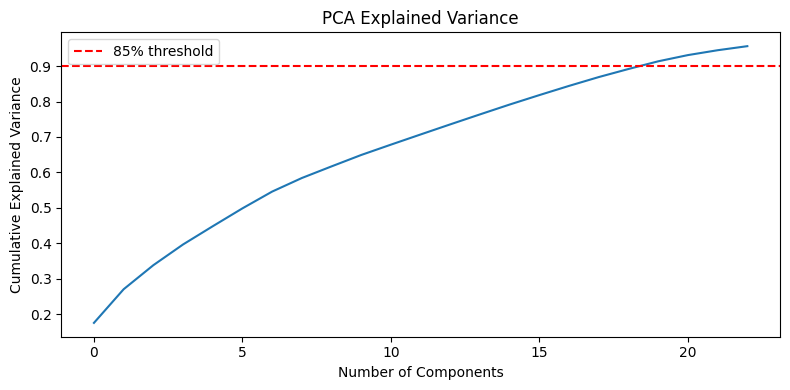

In [168]:
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(0.9, color='red', linestyle='--', label='85% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

### Kmeans - Elbow

In [169]:
inertias = []
silhouettes = []
K_range = range(2, 11)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in K_range:
    km = KMeans(n_clusters=k, random_state=121, n_init=10)  # k-means++ is actually default but explicit here
    labels = km.fit_predict(X_pca, sample_weight=X_weight)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels, sample_size=5000, random_state=42))
    print(f"k={k} | silhouette={silhouettes[-1]:.4f}")

k=2 | silhouette=0.1478
k=3 | silhouette=0.1201
k=4 | silhouette=0.1577
k=5 | silhouette=0.1629
k=6 | silhouette=0.1590
k=7 | silhouette=0.1565
k=8 | silhouette=0.1472
k=9 | silhouette=0.1487
k=10 | silhouette=0.1578


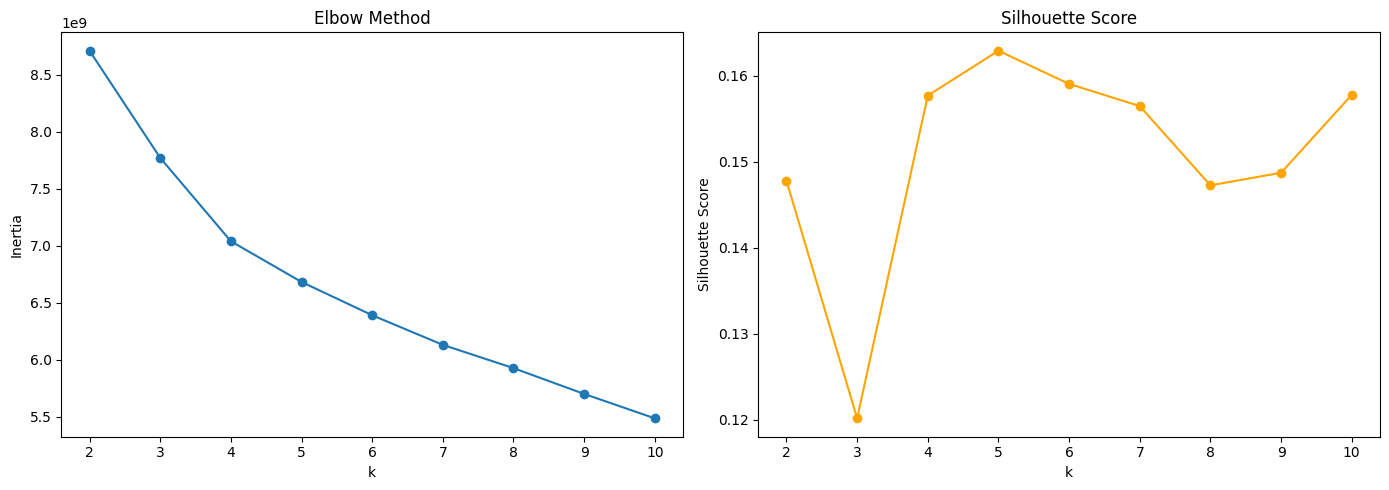

In [170]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [ ]:
# Best K = 5

### GMM Experiment

In [160]:
from sklearn.mixture import GaussianMixture

bics = []
aics = []
silhouettes_gmm = []

for k in range(2,11):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(X_pca)
    labels = gmm.predict(X_pca)


    bics.append(gmm.bic(X_pca))
    aics.append(gmm.aic(X_pca))
    silhouettes_gmm.append(silhouette_score(X_pca, labels, sample_size=5000, random_state=42))
    print(f"k={k} \n BIC={bics[-1]:.0f} \n AIC={aics[-1]:.0f} \n silhouette={silhouettes_gmm[-1]:.4f}")

k=2 
 BIC=5919176 
 AIC=5914595 
 silhouette=0.1436
k=3 
 BIC=3625944 
 AIC=3619068 
 silhouette=0.0977
k=4 
 BIC=1684440 
 AIC=1675267 
 silhouette=0.0952
k=5 
 BIC=-721149 
 AIC=-732617 
 silhouette=0.1018
k=6 
 BIC=-1262307 
 AIC=-1276070 
 silhouette=0.1300
k=7 
 BIC=-1053865 
 AIC=-1069924 
 silhouette=0.1377
k=8 
 BIC=-713486 
 AIC=-731841 
 silhouette=0.1438
k=9 
 BIC=-2949295 
 AIC=-2969945 
 silhouette=0.1242
k=10 
 BIC=-3027528 
 AIC=-3050474 
 silhouette=0.1457


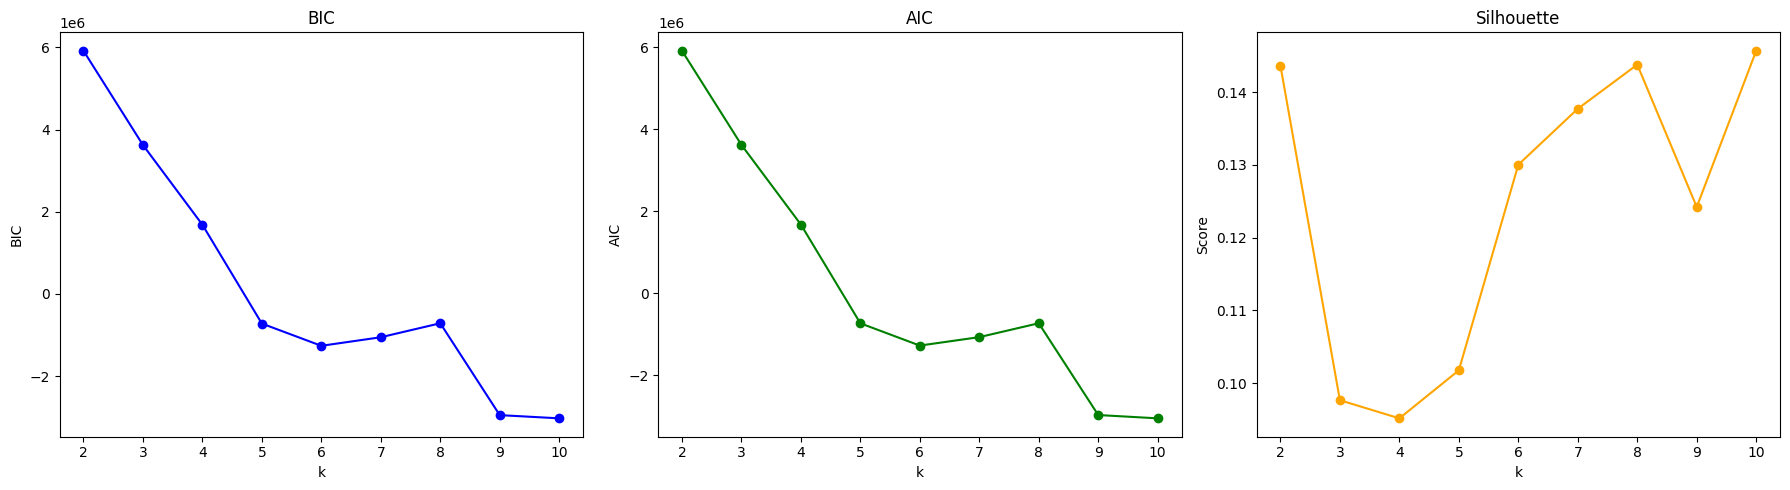

In [161]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(2,11), bics, marker='o', color='blue')
axes[0].set_title('BIC')
axes[0].set_xlabel('k')
axes[0].set_ylabel('BIC')

axes[1].plot(range(2,11), aics, marker='o', color='green')
axes[1].set_title('AIC')
axes[1].set_xlabel('k')
axes[1].set_ylabel('AIC')

axes[2].plot(range(2,11), silhouettes_gmm, marker='o', color='orange')
axes[2].set_title('Silhouette')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [ ]:
# Bad silhouette score on the sample than K means

## Final Model: Kmeans with k = 5

In [183]:
df5 = pd.concat([df3, df[['weight', 'label']]], axis=1)

In [184]:
# Final Model Kmeans with k = 5
from sklearn.cluster import KMeans
km_final = KMeans(n_clusters=5, random_state=121,n_init=10)
df5['segment'] = km_final.fit_predict(X_pca)
print(df5['segment'].value_counts().sort_index())

segment
0    19700
1    45487
2    37389
3    32831
4    17489
Name: count, dtype: int64


PCA Visualization

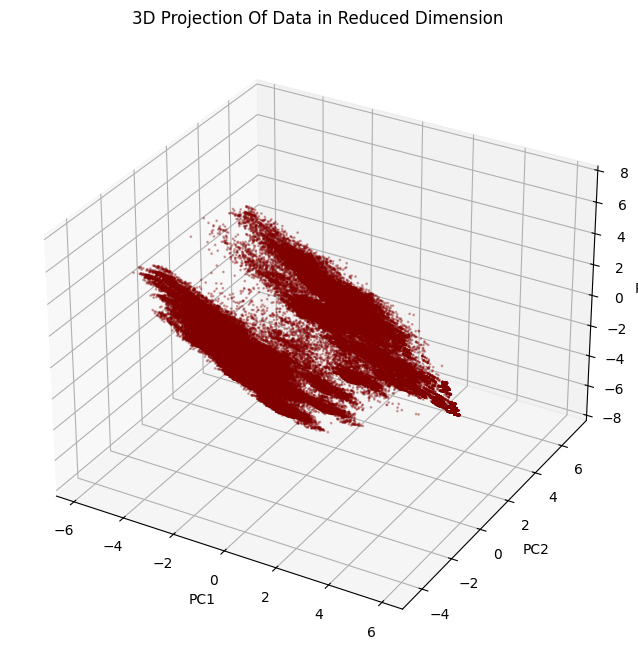

In [185]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Plot
x = X_pca_3d[:, 0]
y = X_pca_3d[:, 1]
z = X_pca_3d[:, 2]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x, y, z, c="maroon", marker="o", alpha=0.3, s=1)
ax.set_title("3D Projection Of Data in Reduced Dimension")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

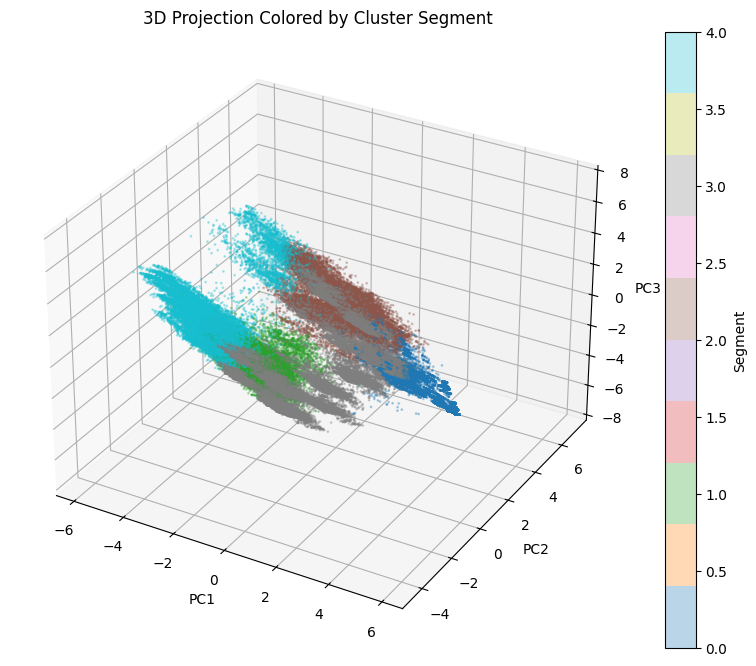

In [186]:
# Color by cluster segment on 3 component PCA
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(x, y, z, c=df2['segment'], cmap='tab10', marker="o", alpha=0.3, s=1)
plt.colorbar(scatter, label='Segment')
ax.set_title("3D Projection Colored by Cluster Segment")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

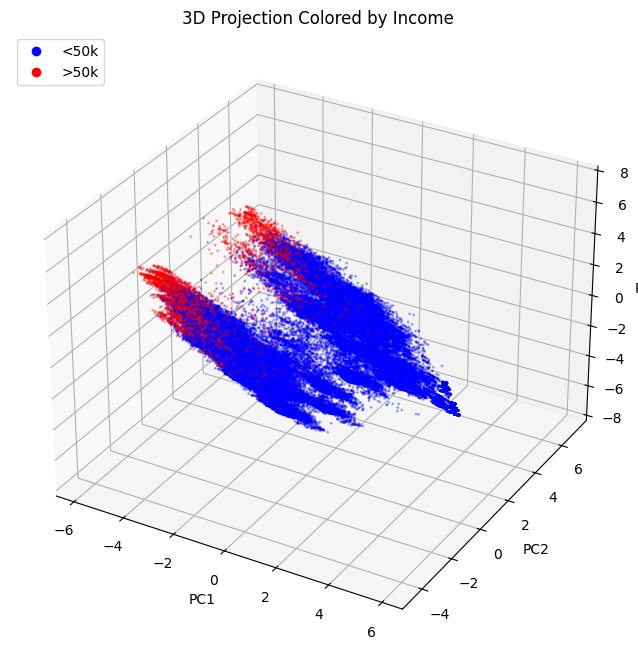

In [187]:
# Color by income on 3 component PCA
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
colors = df['label'].map({0: 'blue', 1: 'red'})

scatter = ax.scatter(x, y, z, color=colors, marker="o", alpha=0.3, s=1)
ax.set_title("3D Projection Colored by Income")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='<50k'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='>50k')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.show()

## Customer Profiling

In [201]:
print(df5.columns)

Index(['age', 'education', 'race', 'has_capital_income', 'is_working',
       'annual_wage', 'foreign_born', 'marital_flag', 'wage_flag',
       'capital_gains_flag', 'capital_losses_flag', 'dividend_flag',
       'weeks_worked_gt_45', 'class_of_worker', 'sex_Male', 'occupation_group',
       'tax_filer_group', 'family_stat_group', 'is_unemployed',
       'has_children_u18', 'is_self_employed_or_biz',
       'income_prediction_score', 'segment', 'weight', 'label'],
      dtype='object')


In [188]:
df5.segment.value_counts()

,count
segment,
1,45487
2,37389
3,32831
0,19700
4,17489


In [191]:
weight_summary = df5.groupby('segment')['weight'].sum().reset_index()
weight_summary.columns = ['segment', 'total_weight']
weight_summary['pct_of_population'] = (weight_summary['total_weight'] / weight_summary['total_weight'].sum() * 100).round(2)

print(weight_summary)

   segment  total_weight  pct_of_population
0        0   97807744.80              28.17
1        1   78136743.11              22.50
2        2   70648302.57              20.35
3        3   70116699.07              20.19
4        4   30536402.92               8.79


In [192]:
df5.groupby('segment')['label'].mean()

,label
segment,
0,0.000000
1,0.088948
2,0.034770
3,0.013463
4,0.376179


In [220]:
num_cols = df5.select_dtypes(exclude='object').columns.tolist()
cat_cols  = df5.select_dtypes(include='object').columns.tolist()

In [221]:
num_cols.remove('weight')
num_cols.remove('segment')

In [222]:
print(num_cols,cat_cols)

['age', 'education', 'has_capital_income', 'is_working', 'annual_wage', 'foreign_born', 'marital_flag', 'wage_flag', 'capital_gains_flag', 'capital_losses_flag', 'dividend_flag', 'weeks_worked_gt_45', 'sex_Male', 'is_unemployed', 'has_children_u18', 'is_self_employed_or_biz', 'income_prediction_score', 'label'] ['race', 'class_of_worker', 'occupation_group', 'tax_filer_group', 'family_stat_group']


In [223]:
def weighted_mean(df, cols, weight_col='weight'):
    rows = {}
    for col in cols:
        rows[col] = np.average(df[col], weights=df[weight_col])
    return pd.Series(rows)

weighted_profile = df5.groupby('segment').apply(lambda x: weighted_mean(x, num_cols)).round(2)
print(weighted_profile.T)

segment                      0        1        2      3        4
age                       9.21    40.81    32.92  59.21    45.98
education                 2.22    10.88    10.61   9.21    12.65
has_capital_income        0.00     0.00     0.08   0.15     0.98
is_working                0.04     0.98     0.98   0.07     0.97
annual_wage              12.18  5532.00  5132.02   0.00  4441.56
foreign_born              1.00     1.00     1.00   1.00     1.00
marital_flag              0.00     1.00     0.02   0.60     0.86
wage_flag                 0.00     0.11     0.13   0.00     0.07
capital_gains_flag        0.00     0.00     0.03   0.03     0.30
capital_losses_flag       0.00     0.03     0.03   0.01     0.06
dividend_flag             0.00     0.00     0.05   0.13     0.79
weeks_worked_gt_45        0.00     0.89     0.78   0.00     0.90
sex_Male                  0.52     0.52     0.52   0.32     0.63
is_unemployed             0.01     0.04     0.08   0.01     0.02
has_children_u18         

In [225]:
print("=== TOP 3 VALUES PER SEGMENT ===")
for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"{col}")
    print('='*50)
    for seg in sorted(df5['segment'].unique()):
        sub = df5[df5['segment'] == seg]
        top3 = sub[col].value_counts(normalize=True).head(3) * 100
        print(f"\nSegment {seg}:")
        print(top3.round(1))

=== TOP 3 VALUES PER SEGMENT ===

race

Segment 0:
race
White                        67.4
Black                        14.8
Asian or Pacific Islander     7.8
Name: proportion, dtype: float64

Segment 1:
race
White                        87.7
Black                         6.7
Asian or Pacific Islander     3.1
Name: proportion, dtype: float64

Segment 2:
race
White                        81.3
Black                        13.0
Asian or Pacific Islander     2.6
Name: proportion, dtype: float64

Segment 3:
race
White                        82.9
Black                        11.1
Asian or Pacific Islander     3.4
Name: proportion, dtype: float64

Segment 4:
race
White                        92.8
Black                         3.4
Asian or Pacific Islander     2.7
Name: proportion, dtype: float64

class_of_worker

Segment 0:
class_of_worker
Not Working    91.5
Private         7.2
Government      0.8
Name: proportion, dtype: float64

Segment 1:
class_of_worker
Private          67.5
Government   

Segment 0: Dependents / Children (28%) <br>
* Average age of 9, with 88% classified as "Child" in family status and 98% not working. These are minors with virtually no income signal.


Segment 1: Core Working Families (22%) <br>
* Average age of 41, with 98% employed and 99% filing jointly. Most are married wage earners in dual-role households. Despite being fully employed, the low income prediction score (0.09) suggests the majority earn under $50k.


Segment 2: Independent Workers (20%) <br>
* Average age of 33, with 98% working and 96% filing as single. Over half fall under "Other" family status, suggesting they are unmarried, not heading a household, and likely in the early stages of their career.


Segment 3: Older Non-Working Adults (20%) <br>
* Average age of 59, with only 7% still employed. Filing status and household roles are mixed, pointing to a retirement or near-retirement population, some of whom remain married to working spouses.


Segment 4: High Income Group (9%) <br>
* Average age of 46, with 97% employed, 79% receiving dividend income, high average education level (12.65) and nearly all reporting capital gains. Predominantly married, male, and highly educated, this segment carries the highest income prediction score (0.38)

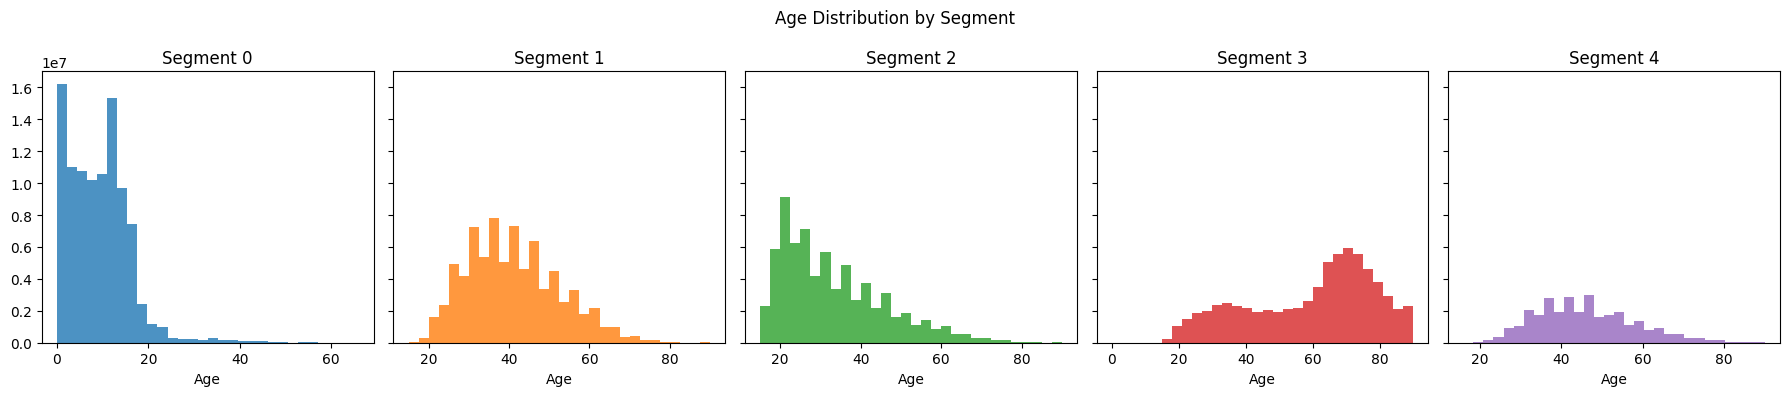

In [226]:
import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution by segment
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for seg in range(5):
    sub = df5[df5['segment'] == seg]
    axes[seg].hist(sub['age'], weights=sub['weight'], bins=30, color=f'C{seg}', alpha=0.8)
    axes[seg].set_title(f'Segment {seg}')
    axes[seg].set_xlabel('Age')
plt.suptitle('Age Distribution by Segment')
plt.tight_layout()
plt.show()

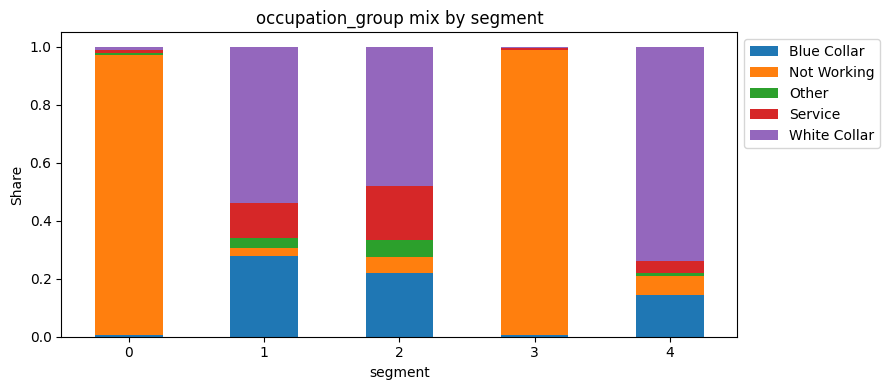

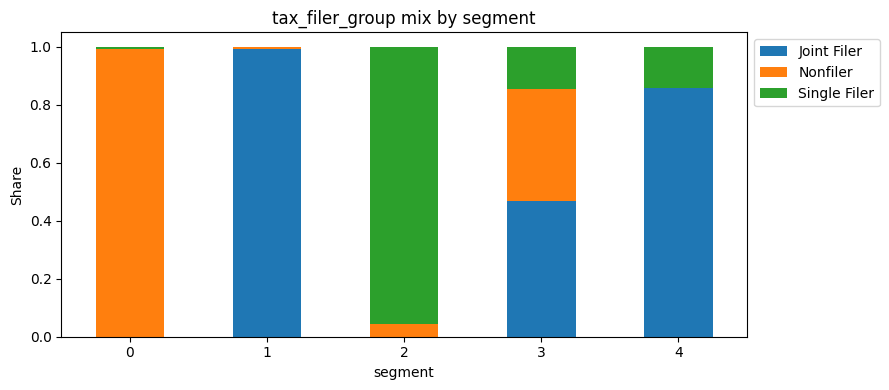

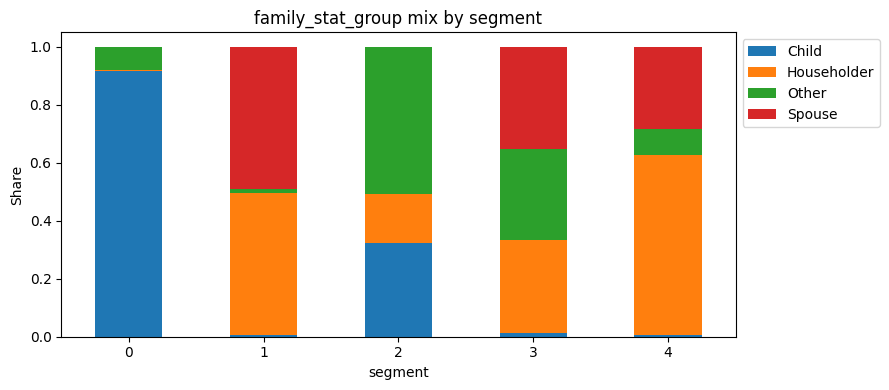

In [228]:
# Categorical breakdown - occupation, tax filer, family status
for col in ['occupation_group', 'tax_filer_group', 'family_stat_group']:
    ct = df5.groupby(['segment', col])['weight'].sum().unstack(fill_value=0)
    ct = ct.div(ct.sum(axis=1), axis=0)  # normalize to %
    ct.plot(kind='bar', stacked=True, figsize=(9, 4))
    plt.title(f'{col} mix by segment')
    plt.ylabel('Share')
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()